# 🏢 HR Analytics — Employee Attrition Analysis
**A complete Data Analysis & Visualization Project**

### Project Goal:
Understand WHY employees leave the company by analyzing key factors driving attrition.

### Steps:
1. Setup & Data Loading
2. SQL-Based Exploration
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Data Visualization
6. Key Insights & Recommendations

---
## 📦 STEP 1: Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn plotly

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import warnings

warnings.filterwarnings('ignore')

# Ensure stdout can print Unicode (emoji) on Windows consoles whose default
# encoding is cp1252. Safe no-op on platforms/Pythons that don't support it.
try:
    sys.stdout.reconfigure(encoding='utf-8')
except Exception:
    pass

# Make sure the output directory for chart PNGs exists.
VISUALS_DIR = 'visuals'
os.makedirs(VISUALS_DIR, exist_ok=True)

# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')


✅ All libraries imported successfully!


---
## 📂 STEP 2: Load the Dataset

📥 **Download the dataset first:**
1. Go to: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
2. Download `WA_Fn-UseC_-HR-Employee-Attrition.csv`
3. Place it in the `data/` folder inside this project

In [2]:
# Load the dataset (use a path relative to the notebook so it runs anywhere)
CSV_PATH = os.path.join('archive', 'WA_Fn-UseC_-HR-Employee-Attrition.csv')
df = pd.read_csv(CSV_PATH)

print(f'✅ Dataset loaded successfully!')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n🔍 First 5 rows:')
df.head()


✅ Dataset loaded successfully!
📊 Shape: 1470 rows × 35 columns

🔍 First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---
## 🗃️ STEP 3: SQL-Based Exploration
We load the data into an in-memory SQLite database and run SQL queries.

In [3]:
# Create in-memory SQLite database
conn = sqlite3.connect(':memory:')
df.to_sql('employees', conn, index=False, if_exists='replace')
print('✅ Data loaded into SQLite database!')

✅ Data loaded into SQLite database!


In [4]:
# SQL Query 1: Overall Attrition Count
query1 = '''
SELECT 
    Attrition,
    COUNT(*) AS Count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM employees), 2) AS Percentage
FROM employees
GROUP BY Attrition
'''
print('📊 SQL Query 1: Overall Attrition')
pd.read_sql_query(query1, conn)

📊 SQL Query 1: Overall Attrition


,Attrition,Count,Percentage
0,No,1233,83.88
1,Yes,237,16.12


In [5]:
# SQL Query 2: Attrition by Department
query2 = '''
SELECT 
    Department,
    COUNT(*) AS Total_Employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Left,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS Attrition_Rate
FROM employees
GROUP BY Department
ORDER BY Attrition_Rate DESC
'''
print('📊 SQL Query 2: Attrition Rate by Department')
pd.read_sql_query(query2, conn)

📊 SQL Query 2: Attrition Rate by Department


,Department,Total_Employees,Left,Attrition_Rate
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


In [6]:
# SQL Query 3: Average Salary by Attrition
query3 = '''
SELECT 
    Attrition,
    ROUND(AVG(MonthlyIncome), 2) AS Avg_Monthly_Income,
    ROUND(AVG(Age), 1) AS Avg_Age,
    ROUND(AVG(YearsAtCompany), 1) AS Avg_Years_At_Company,
    ROUND(AVG(JobSatisfaction), 2) AS Avg_Job_Satisfaction
FROM employees
GROUP BY Attrition
'''
print('📊 SQL Query 3: Key Averages by Attrition')
pd.read_sql_query(query3, conn)

📊 SQL Query 3: Key Averages by Attrition


,Attrition,Avg_Monthly_Income,Avg_Age,Avg_Years_At_Company,Avg_Job_Satisfaction
0,No,6832.74,37.6,7.4,2.78
1,Yes,4787.09,33.6,5.1,2.47


In [7]:
# SQL Query 4: Top 5 Job Roles with Highest Attrition
query4 = '''
SELECT 
    JobRole,
    COUNT(*) AS Total,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Left_Count,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS Attrition_Rate
FROM employees
GROUP BY JobRole
ORDER BY Attrition_Rate DESC
LIMIT 5
'''
print('📊 SQL Query 4: Top 5 Job Roles by Attrition Rate')
pd.read_sql_query(query4, conn)

📊 SQL Query 4: Top 5 Job Roles by Attrition Rate


,JobRole,Total,Left_Count,Attrition_Rate
0,Sales Representative,83,33,39.76
1,Laboratory Technician,259,62,23.94
2,Human Resources,52,12,23.08
3,Sales Executive,326,57,17.48
4,Research Scientist,292,47,16.10


---
## 🧹 STEP 4: Data Cleaning

In [8]:
# Check for null values
print('🔍 Null Values in Dataset:')
print(df.isnull().sum().sum(), 'total nulls found')

# Check for duplicates
print(f'\n🔍 Duplicate Rows: {df.duplicated().sum()}')

# Basic info
print('\n📋 Data Types:')
df.info()

🔍 Null Values in Dataset:
0 total nulls found

🔍 Duplicate Rows: 0

📋 Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement        

In [9]:
# Drop columns with no useful variation
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_clean = df.drop(columns=cols_to_drop)

# Encode target column: Attrition (Yes=1, No=0)
df_clean['AttritionBinary'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# Create Age Groups (include_lowest=True so age==18 isn't dropped to NaN)
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[18, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-60'],
    include_lowest=True
)

# Create Income Groups (use np.inf as upper bound to avoid dropping high incomes)
df_clean['IncomeGroup'] = pd.cut(
    df_clean['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, np.inf],
    labels=['Low (<3K)', 'Medium (3-6K)', 'High (6-10K)', 'Very High (>10K)']
)

print(f'✅ Data cleaned! Shape: {df_clean.shape}')
print(f'\nNew columns added: AttritionBinary, AgeGroup, IncomeGroup')


✅ Data cleaned! Shape: (1470, 34)

New columns added: AttritionBinary, AgeGroup, IncomeGroup


---
## 🔍 STEP 5: Exploratory Data Analysis (EDA)

In [10]:
# Basic statistics
print('📊 Summary Statistics (Numerical Columns):')
df_clean.describe().round(2)

📊 Summary Statistics (Numerical Columns):


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionBinary
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,2.72,65.89,2.73,2.06,2.73,6502.93,...,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12,0.16
std,9.14,403.51,8.11,1.02,1.09,20.33,0.71,1.11,1.10,4707.96,...,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57,0.37
min,18.00,102.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,2.00,48.00,2.00,1.00,2.00,2911.00,...,2.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00,0.00
50%,36.00,802.00,7.00,3.00,3.00,66.00,3.00,2.00,3.00,4919.00,...,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00,0.00
75%,43.00,1157.00,14.00,4.00,4.00,83.75,3.00,3.00,4.00,8379.00,...,4.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00,0.00
max,60.00,1499.00,29.00,5.00,4.00,100.00,4.00,5.00,4.00,19999.00,...,4.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00,1.00


In [11]:
# Attrition distribution
attrition_counts = df_clean['Attrition'].value_counts()
attrition_pct = df_clean['Attrition'].value_counts(normalize=True) * 100

print('📊 Overall Attrition Distribution:')
print(f'  Stayed  : {attrition_counts["No"]}  ({attrition_pct["No"]:.1f}%)')
print(f'  Left    : {attrition_counts["Yes"]}  ({attrition_pct["Yes"]:.1f}%)')
print(f'\n⚠️  Attrition Rate: {attrition_pct["Yes"]:.1f}%')

📊 Overall Attrition Distribution:
  Stayed  : 1233  (83.9%)
  Left    : 237  (16.1%)

⚠️  Attrition Rate: 16.1%


In [12]:
# Attrition by key categorical variables
categorical_cols = ['Department', 'JobRole', 'Gender', 'MaritalStatus', 'OverTime']

for col in categorical_cols:
    attrition_by = df_clean.groupby(col)['AttritionBinary'].mean() * 100
    print(f'\n📌 Attrition Rate by {col}:')
    print(attrition_by.sort_values(ascending=False).round(1).to_string())


📌 Attrition Rate by Department:
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8



📌 Attrition Rate by JobRole:
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Manufacturing Director        6.9
Healthcare Representative     6.9
Manager                       4.9
Research Director             2.5

📌 Attrition Rate by Gender:
Gender
Male      17.0
Female    14.8

📌 Attrition Rate by MaritalStatus:
MaritalStatus
Single      25.5
Married     12.5
Divorced    10.1

📌 Attrition Rate by OverTime:
OverTime
Yes    30.5
No     10.4


---
## 📊 STEP 6: Data Visualization

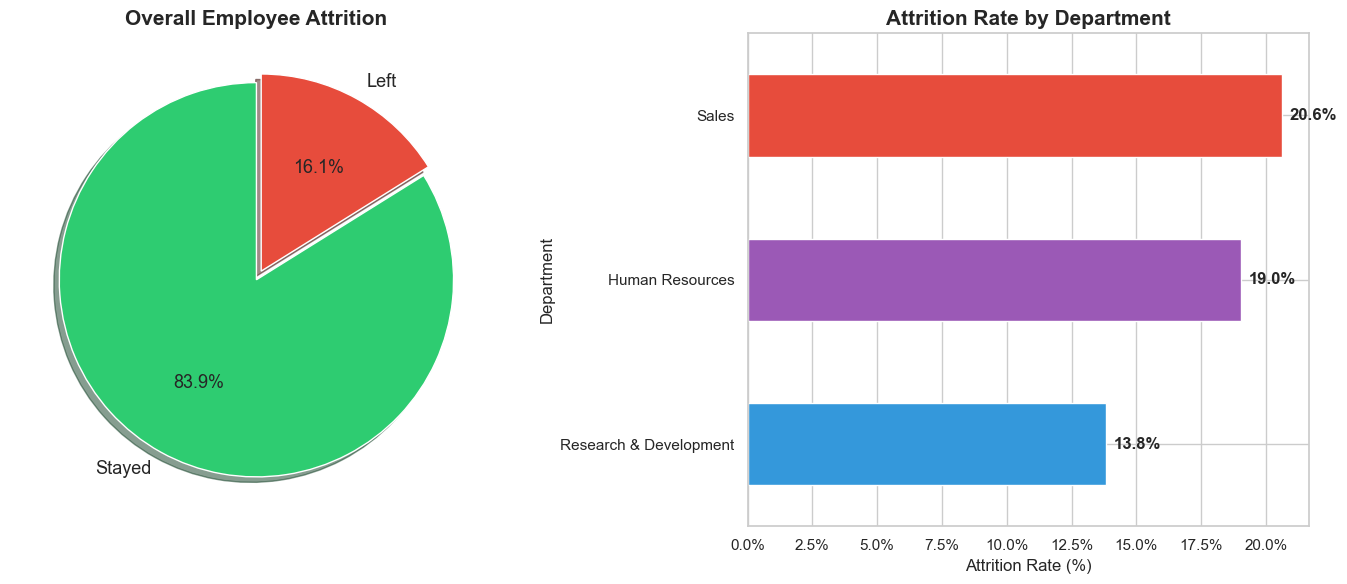

💾 Chart saved!


In [13]:
# ── Chart 1: Overall Attrition Pie Chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(
    attrition_counts,
    labels=['Stayed', 'Left'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05),
    shadow=True,
    textprops={'fontsize': 13}
)
axes[0].set_title('Overall Employee Attrition', fontsize=15, fontweight='bold')

# Bar chart
attrition_dept = df_clean.groupby('Department')['AttritionBinary'].mean() * 100
attrition_dept.sort_values().plot(kind='barh', ax=axes[1], color=['#3498db', '#9b59b6', '#e74c3c'])
axes[1].set_title('Attrition Rate by Department', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(attrition_dept.sort_values()):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/01_overall_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart saved!')

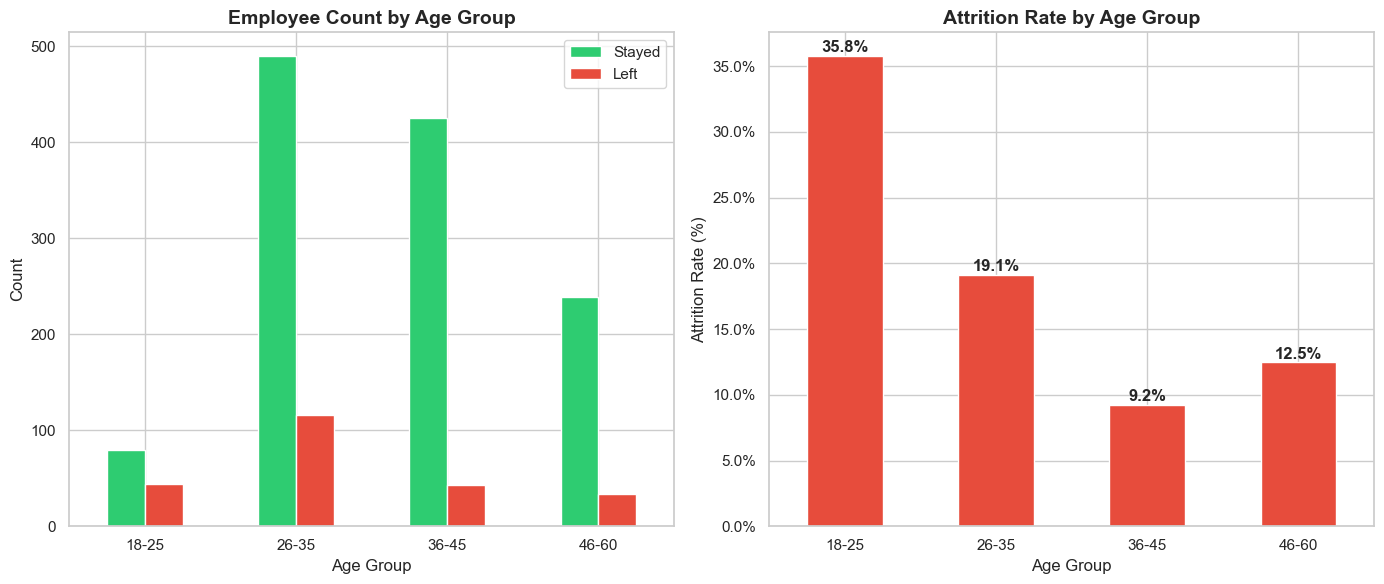

In [14]:
# ── Chart 2: Age Group vs Attrition ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Age distribution
df_clean.groupby(['AgeGroup', 'Attrition']).size().unstack().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='white'
)
axes[0].set_title('Employee Count by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].legend(['Stayed', 'Left'])
axes[0].tick_params(axis='x', rotation=0)

# Attrition rate by age group
attrition_age = df_clean.groupby('AgeGroup')['AttritionBinary'].mean() * 100
attrition_age.plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(attrition_age):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/02_age_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

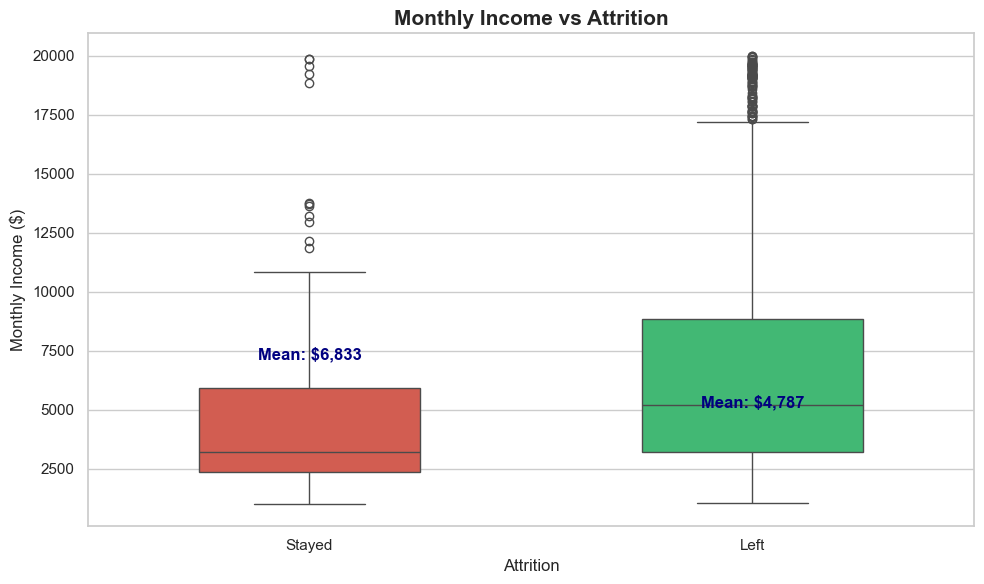

In [15]:
# ── Chart 3: Monthly Income vs Attrition (Box Plot) ──
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x='Attrition',
    y='MonthlyIncome',
    palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
    width=0.5
)
plt.title('Monthly Income vs Attrition', fontsize=15, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')
plt.xticks([0, 1], ['Stayed', 'Left'])

# Add mean annotations
for i, status in enumerate(['No', 'Yes']):
    mean_val = df_clean[df_clean['Attrition'] == status]['MonthlyIncome'].mean()
    plt.text(i, mean_val + 300, f'Mean: ${mean_val:,.0f}', ha='center', fontweight='bold', color='navy')

plt.tight_layout()
plt.savefig('visuals/03_income_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 800x600 with 0 Axes>

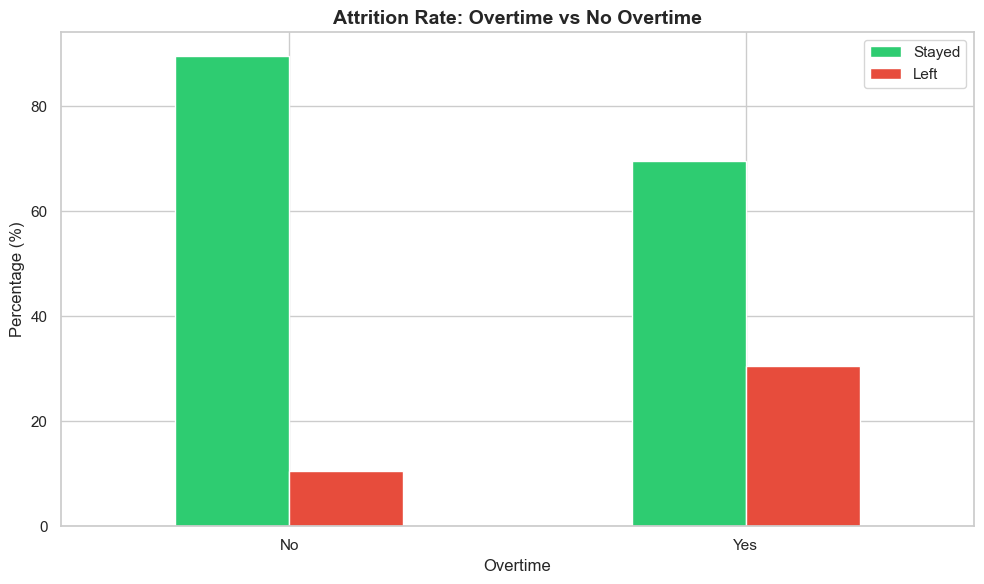

In [16]:
# ── Chart 4: Overtime vs Attrition ──
overtime_data = df_clean.groupby(['OverTime', 'Attrition']).size().unstack()
overtime_pct = overtime_data.div(overtime_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 6))
overtime_pct.plot(
    kind='bar',
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    width=0.5
)
plt.title('Attrition Rate: Overtime vs No Overtime', fontsize=14, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Percentage (%)')
plt.legend(['Stayed', 'Left'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('visuals/04_overtime_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

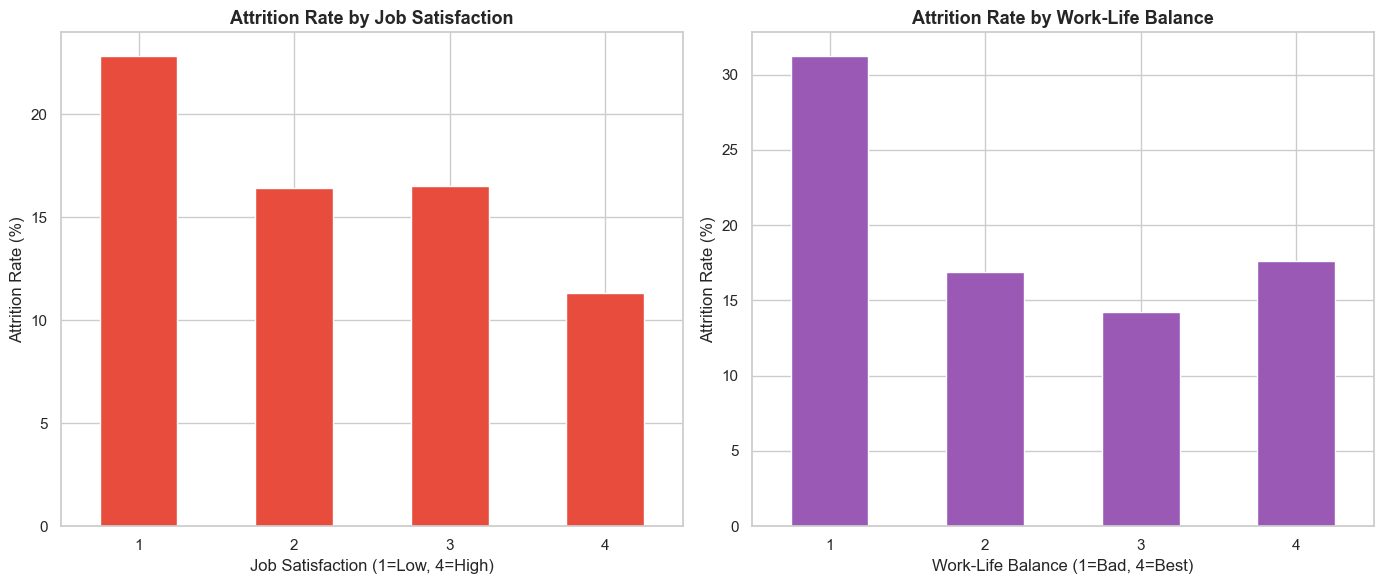

In [17]:
# ── Chart 5: Job Satisfaction vs Attrition ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Job Satisfaction
sat_data = df_clean.groupby(['JobSatisfaction', 'Attrition']).size().unstack()
sat_pct = sat_data.div(sat_data.sum(axis=1), axis=0) * 100
sat_pct['Yes'].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('Attrition Rate by Job Satisfaction', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Job Satisfaction (1=Low, 4=High)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Work-Life Balance
wlb_data = df_clean.groupby(['WorkLifeBalance', 'Attrition']).size().unstack()
wlb_pct = wlb_data.div(wlb_data.sum(axis=1), axis=0) * 100
wlb_pct['Yes'].plot(kind='bar', ax=axes[1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Attrition Rate by Work-Life Balance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Work-Life Balance (1=Bad, 4=Best)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('visuals/05_satisfaction_wlb.png', dpi=150, bbox_inches='tight')
plt.show()

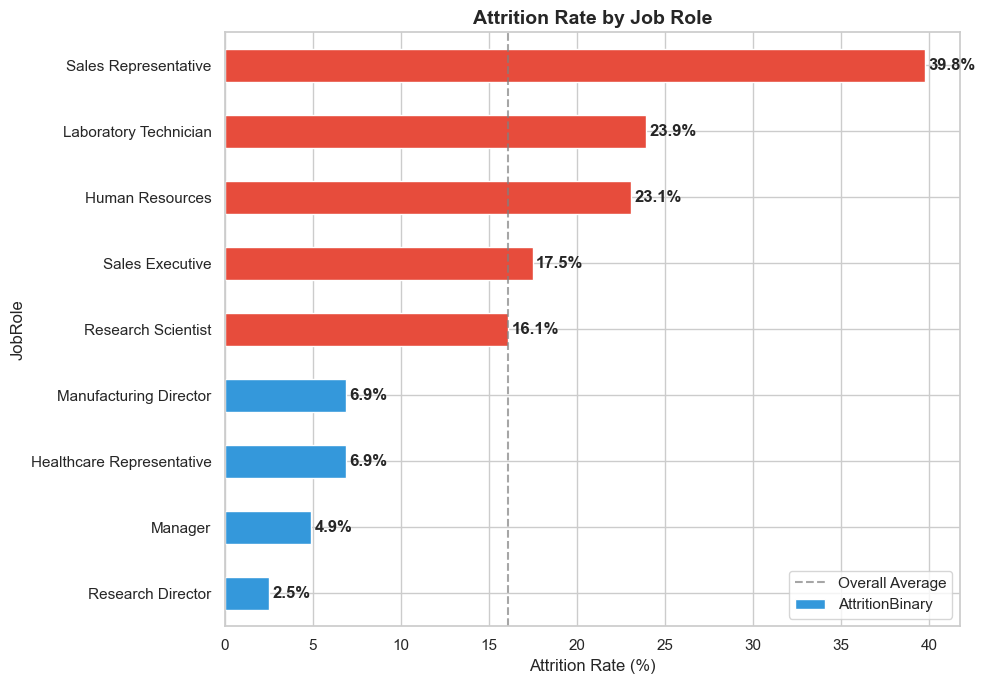

In [18]:
# ── Chart 6: Top 10 Job Roles Attrition ──
jobrole_attr = df_clean.groupby('JobRole')['AttritionBinary'].mean() * 100
jobrole_attr = jobrole_attr.sort_values(ascending=True)

colors_list = ['#e74c3c' if x > 15 else '#3498db' for x in jobrole_attr]

plt.figure(figsize=(10, 7))
jobrole_attr.plot(kind='barh', color=colors_list, edgecolor='white')
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.axvline(x=16.1, linestyle='--', color='gray', alpha=0.7, label='Overall Average')
for i, v in enumerate(jobrole_attr):
    plt.text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('visuals/06_jobrole_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

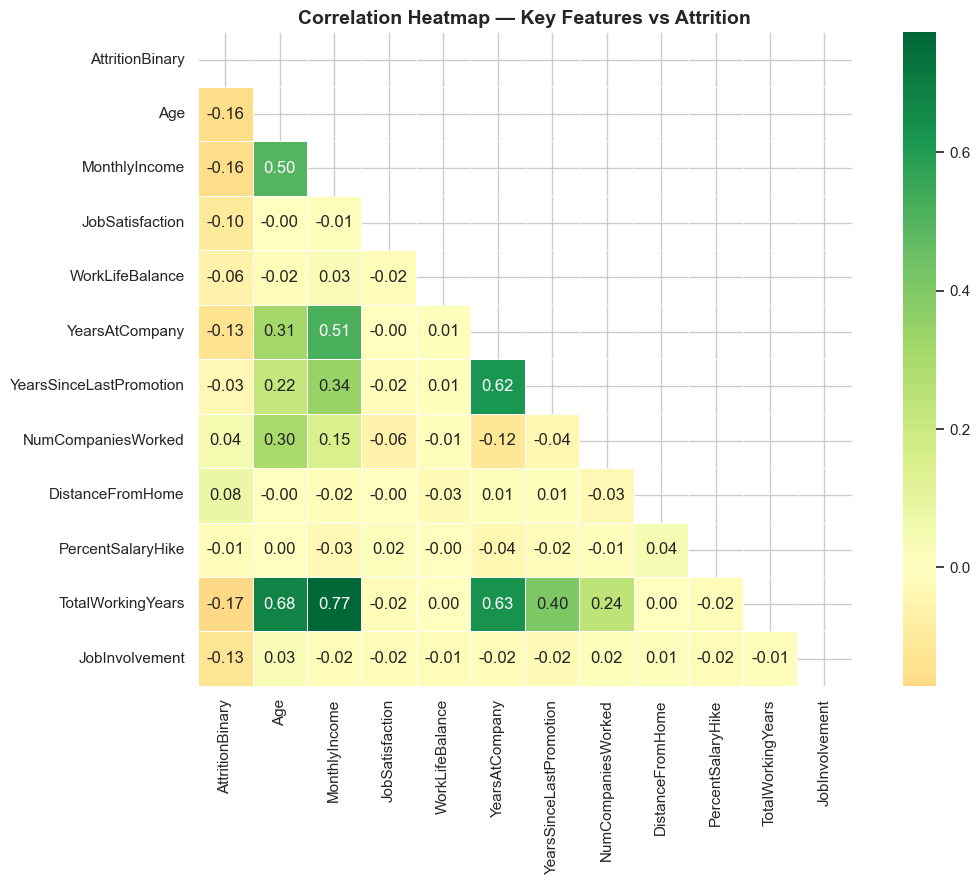


📌 Key correlations with AttritionBinary:
TotalWorkingYears         -0.171
MonthlyIncome             -0.160
Age                       -0.159
YearsAtCompany            -0.134
JobInvolvement            -0.130
JobSatisfaction           -0.103
WorkLifeBalance           -0.064
YearsSinceLastPromotion   -0.033
PercentSalaryHike         -0.013
NumCompaniesWorked         0.043
DistanceFromHome           0.078


In [19]:
# ── Chart 7: Correlation Heatmap ──
# Select numerical columns relevant to attrition
num_cols = [
    'AttritionBinary', 'Age', 'MonthlyIncome', 'JobSatisfaction',
    'WorkLifeBalance', 'YearsAtCompany', 'YearsSinceLastPromotion',
    'NumCompaniesWorked', 'DistanceFromHome', 'PercentSalaryHike',
    'TotalWorkingYears', 'JobInvolvement'
]

corr = df_clean[num_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — Key Features vs Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Key correlations with AttritionBinary:')
print(corr['AttritionBinary'].drop('AttritionBinary').sort_values().round(3).to_string())

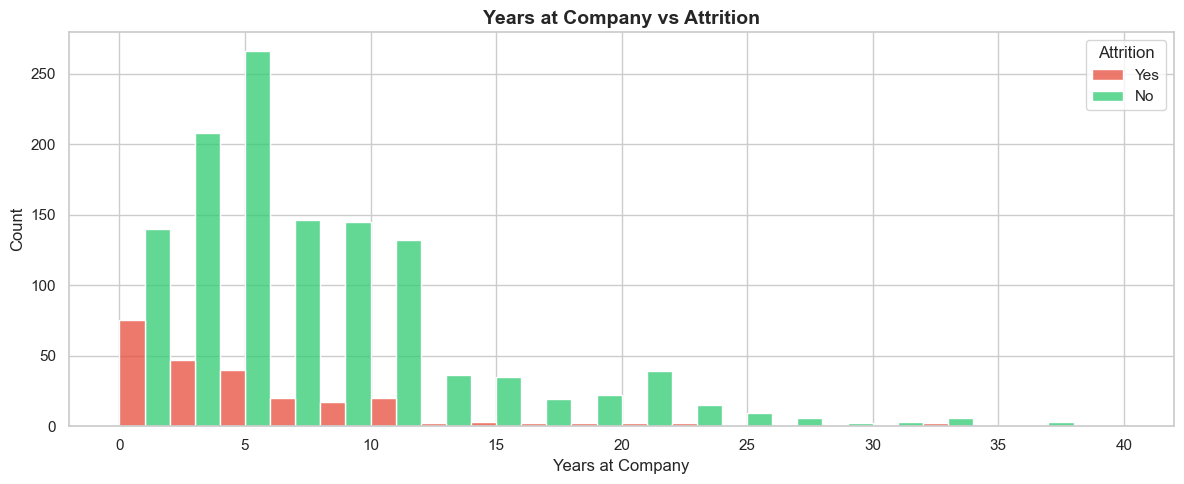

In [20]:
# ── Chart 8: Years at Company vs Attrition ──
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df_clean,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='dodge',
    palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
    bins=20,
    edgecolor='white'
)
plt.title('Years at Company vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('visuals/08_years_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── Chart 9: Interactive Plotly Chart — Income by Dept & Attrition ──
fig = px.box(
    df_clean,
    x='Department',
    y='MonthlyIncome',
    color='Attrition',
    color_discrete_map={'No': '#2ecc71', 'Yes': '#e74c3c'},
    title='Monthly Income Distribution by Department & Attrition',
    labels={'MonthlyIncome': 'Monthly Income ($)', 'Department': 'Department'},
    template='plotly_white'
)
fig.update_layout(title_font_size=16)
fig.show()

In [22]:
# ── Chart 10: Interactive Plotly Scatter — Age vs Income ──
fig = px.scatter(
    df_clean,
    x='Age',
    y='MonthlyIncome',
    color='Attrition',
    size='YearsAtCompany',
    hover_data=['JobRole', 'Department'],
    color_discrete_map={'No': '#2ecc71', 'Yes': '#e74c3c'},
    title='Age vs Monthly Income (Size = Years at Company)',
    template='plotly_white',
    opacity=0.7
)
fig.update_layout(title_font_size=16)
fig.show()

---
## 💡 STEP 7: Key Insights & Recommendations

In [23]:
# Calculate key stats for the insights summary
overall_rate = df_clean['AttritionBinary'].mean() * 100
overtime_yes_rate = df_clean[df_clean['OverTime'] == 'Yes']['AttritionBinary'].mean() * 100
overtime_no_rate = df_clean[df_clean['OverTime'] == 'No']['AttritionBinary'].mean() * 100
young_rate = df_clean[df_clean['AgeGroup'] == '18-25']['AttritionBinary'].mean() * 100
lowsat_rate = df_clean[df_clean['JobSatisfaction'] == 1]['AttritionBinary'].mean() * 100
highsat_rate = df_clean[df_clean['JobSatisfaction'] == 4]['AttritionBinary'].mean() * 100
mean_income_left = df_clean[df_clean['Attrition'] == 'Yes']['MonthlyIncome'].mean()
mean_income_stayed = df_clean[df_clean['Attrition'] == 'No']['MonthlyIncome'].mean()

print('=' * 65)
print('          📋 KEY INSIGHTS SUMMARY')
print('=' * 65)

print(f"""
📌 INSIGHT 1 — OVERALL ATTRITION
   Overall attrition rate is {overall_rate:.1f}%.
   This means ~1 in 6 employees leaves the company.

📌 INSIGHT 2 — OVERTIME IS A MAJOR DRIVER
   Employees working overtime: {overtime_yes_rate:.1f}% attrition rate
   Employees NOT working overtime: {overtime_no_rate:.1f}% attrition rate
   → Overtime employees are {overtime_yes_rate/overtime_no_rate:.1f}x more likely to leave!

📌 INSIGHT 3 — YOUNG EMPLOYEES LEAVE MORE
   Age 18-25 attrition rate: {young_rate:.1f}%
   → Youngest employees are the most at-risk group.

📌 INSIGHT 4 — JOB SATISFACTION MATTERS
   Low satisfaction (score 1): {lowsat_rate:.1f}% attrition
   High satisfaction (score 4): {highsat_rate:.1f}% attrition
   → Improving satisfaction can significantly reduce attrition.

📌 INSIGHT 5 — LOWER INCOME = HIGHER ATTRITION
   Average monthly income of those who LEFT:   ${mean_income_left:,.0f}
   Average monthly income of those who STAYED: ${mean_income_stayed:,.0f}
   → Employees who leave earn ~${mean_income_stayed - mean_income_left:,.0f} less on average.
""")

print('=' * 65)
print('          💼 HR RECOMMENDATIONS')
print('=' * 65)
print("""
✅ 1. Review overtime policies — introduce compensatory time off
      or limit mandatory overtime in high-attrition departments.

✅ 2. Create a Young Talent Retention Program — mentoring,
      career progression paths, and bonuses for employees under 25.

✅ 3. Conduct regular satisfaction surveys and take action
      quickly when scores are low.

✅ 4. Review salary benchmarks — especially for Sales Reps
      and Lab Technicians, who show the highest attrition.

✅ 5. Focus retention efforts on employees in their first
      1-3 years at the company (highest risk period).
""")

          📋 KEY INSIGHTS SUMMARY

📌 INSIGHT 1 — OVERALL ATTRITION
   Overall attrition rate is 16.1%.
   This means ~1 in 6 employees leaves the company.

📌 INSIGHT 2 — OVERTIME IS A MAJOR DRIVER
   Employees working overtime: 30.5% attrition rate
   Employees NOT working overtime: 10.4% attrition rate
   → Overtime employees are 2.9x more likely to leave!

📌 INSIGHT 3 — YOUNG EMPLOYEES LEAVE MORE
   Age 18-25 attrition rate: 35.8%
   → Youngest employees are the most at-risk group.

📌 INSIGHT 4 — JOB SATISFACTION MATTERS
   Low satisfaction (score 1): 22.8% attrition
   High satisfaction (score 4): 11.3% attrition
   → Improving satisfaction can significantly reduce attrition.

📌 INSIGHT 5 — LOWER INCOME = HIGHER ATTRITION
   Average monthly income of those who LEFT:   $4,787
   Average monthly income of those who STAYED: $6,833
   → Employees who leave earn ~$2,046 less on average.

          💼 HR RECOMMENDATIONS

✅ 1. Review overtime policies — introduce compensatory time off
      

---
## 🎉 Project Complete!

You have successfully:
- ✅ Loaded and explored data with **SQL queries**
- ✅ Cleaned and engineered features with **Pandas**
- ✅ Built **10 visualizations** using Matplotlib, Seaborn & Plotly
- ✅ Extracted **5 key business insights**
- ✅ Provided **actionable HR recommendations**

### 🚀 Want to go further?
- Build a **Machine Learning model** to predict attrition (Logistic Regression, Random Forest)
- Create a **Streamlit Dashboard** to make it interactive
- Connect to a real **PostgreSQL database** instead of SQLite